In [108]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sqlalchemy import create_engine
import datetime

In [109]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [110]:
query_min = "SELECT * FROM gold.active_1min"
df_min = pd.read_sql(query_min,engine)

In [111]:
df_min['bucket_30min'] = df_min['bar_time'].apply(
    lambda t: (
        datetime.datetime.min + datetime.timedelta(minutes=(t.hour*60 + t.minute)//30 *30)  
    ).time() 
)

df_min['bucket_hr'] = df_min['bar_time'].apply( lambda t: datetime.time(t.hour,0,0))

In [112]:
df_min['price_movement'] = df_min['high']-df_min['low']
df_day = df_min.groupby('bar_date')['price_movement'].agg('sum').reset_index()
df_hr = df_min.groupby(['bar_date','bucket_hr'])['price_movement'].agg('sum').reset_index()
df_30 = df_min.groupby(['bar_date','bucket_30min'])['price_movement'].agg('sum').reset_index()

Daily Analysis

In [113]:
print(df_day['price_movement'].describe())
print('Median: ',df_day['price_movement'].median())
print("Std Dev: ",df_day['price_movement'].std())
print("IQR:", df_day['price_movement'].quantile(0.75) - df_day['price_movement'].quantile(0.25))

count     239.000000
mean      482.323222
std       376.043583
min        29.750000
25%       276.125000
50%       380.750000
75%       541.375000
max      3287.250000
Name: price_movement, dtype: float64
Median:  380.75
Std Dev:  376.0435834499272
IQR: 265.25


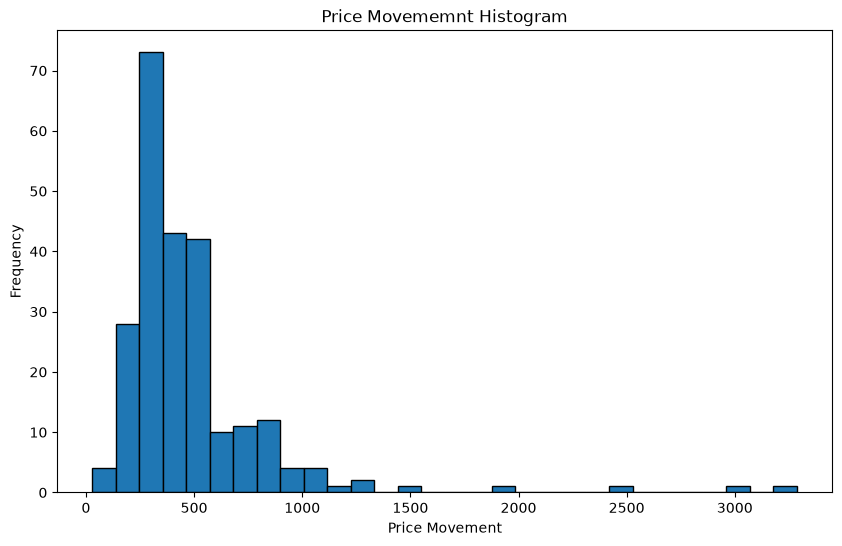

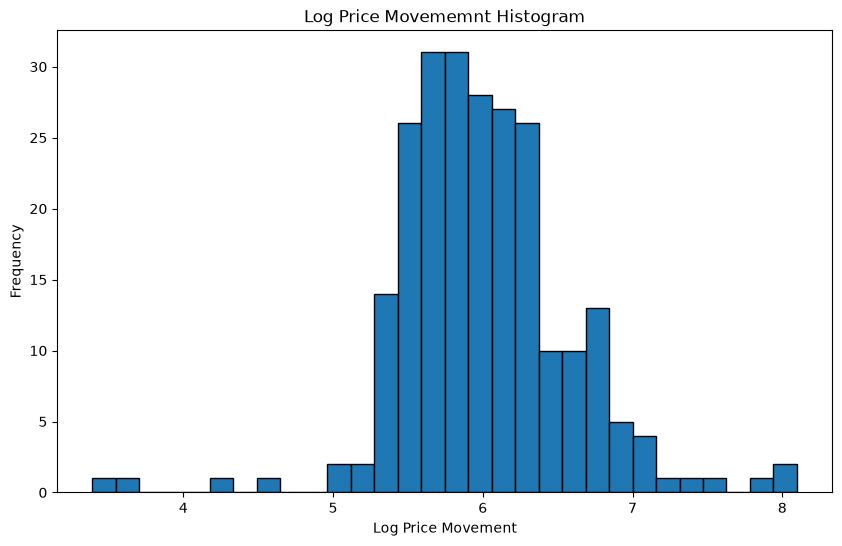

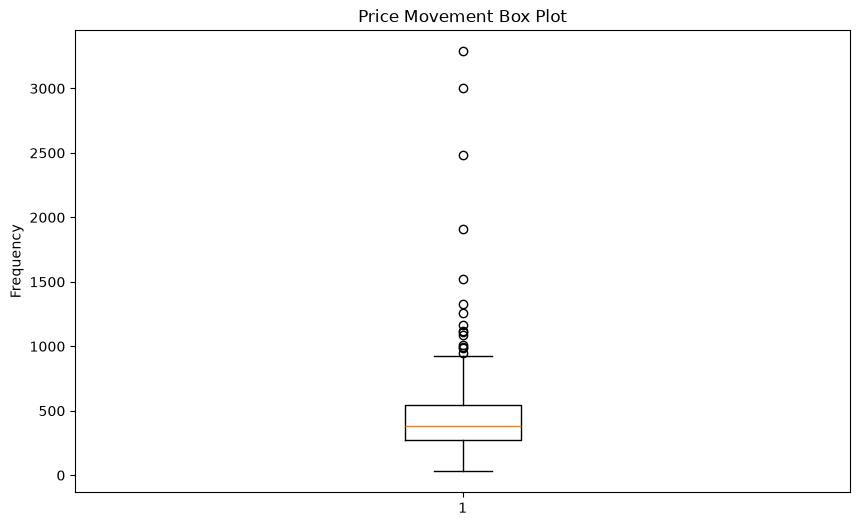

In [114]:
plt.figure(figsize=(10,6))
plt.hist(df_day['price_movement'],bins=30,edgecolor='black')
plt.xlabel('Price Movement')
plt.ylabel('Frequency')
plt.title('Price Movememnt Histogram')

plt.show()

df_day['log_price_movement'] = np.log(df_day['price_movement'])
plt.figure(figsize=(10,6))
plt.hist(df_day['log_price_movement'],bins=30,edgecolor='black')
plt.xlabel('Log Price Movement')
plt.ylabel('Frequency')
plt.title('Log Price Movememnt Histogram')

plt.show()

plt.figure(figsize=(10,6))
plt.boxplot(df_day['price_movement'])
plt.ylabel('Frequency')
plt.title('Price Movement Box Plot')

plt.show()

Hour Analysis

In [115]:
agg_hr = df_hr.groupby('bucket_hr')['price_movement'].agg(['mean','median','std'])
df_hr['q1'] = df_hr.groupby('bucket_hr')['price_movement'].transform(lambda x: x.quantile(.25))
df_hr['q3'] = df_hr.groupby('bucket_hr')['price_movement'].transform(lambda x: x.quantile(.75))
df_hr_IQR = df_hr[(df_hr['price_movement']>=df_hr['q1'])&(df_hr['price_movement']<=df_hr['q3'])]
agg_hr_IQR = df_hr_IQR.groupby('bucket_hr')['price_movement'].agg(['mean','median','std'])

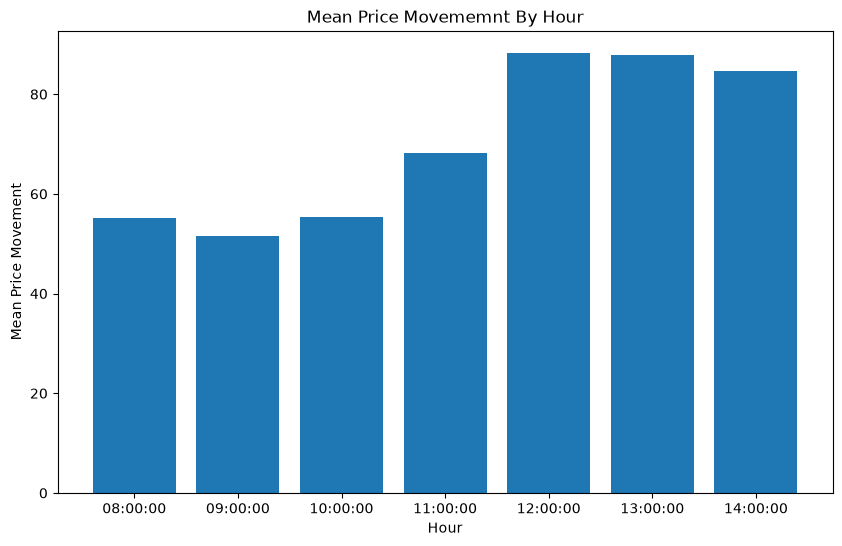

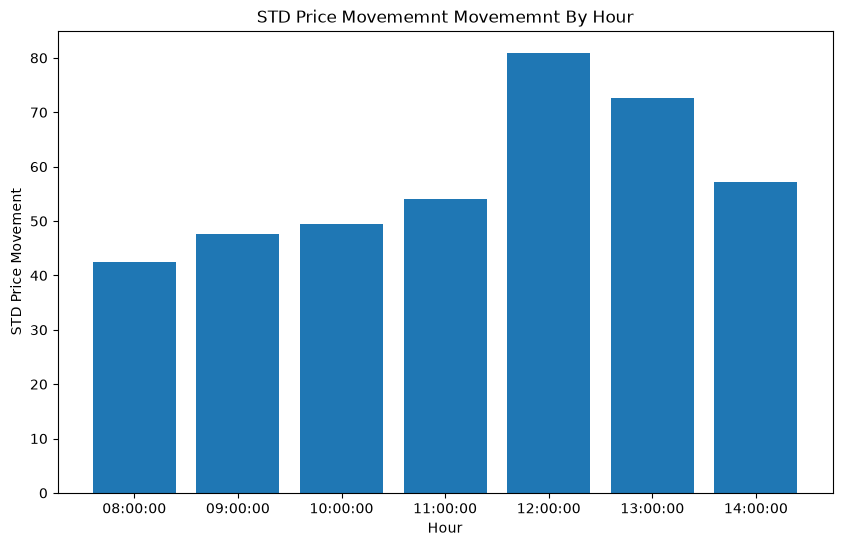

In [116]:
plt.figure(figsize=(10,6))
plt.bar(agg_hr.index.astype(str),agg_hr['mean'])
plt.xlabel('Hour')
plt.ylabel('Mean Price Movement')
plt.title('Mean Price Movememnt By Hour')

plt.show()


plt.figure(figsize=(10,6))
plt.bar(agg_hr.index.astype(str),agg_hr['std'])
plt.xlabel('Hour')
plt.ylabel('STD Price Movement')
plt.title('STD Price Movememnt Movememnt By Hour')

plt.show()

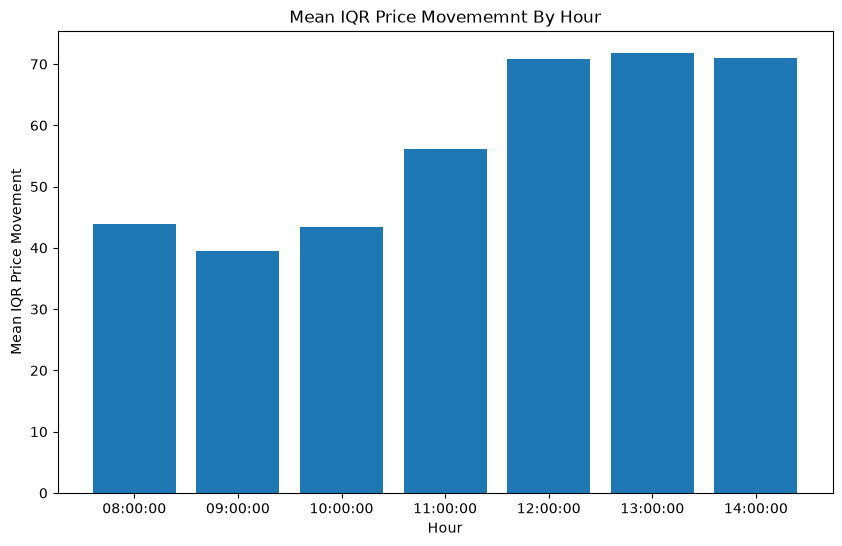

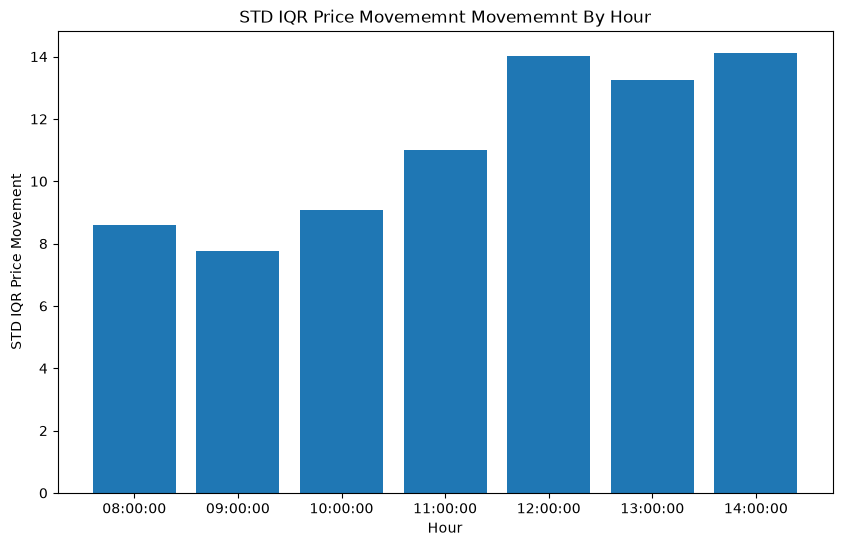

In [117]:
plt.figure(figsize=(10,6))
plt.bar(agg_hr_IQR.index.astype(str),agg_hr_IQR['mean'])
plt.xlabel('Hour')
plt.ylabel('Mean IQR Price Movement')
plt.title('Mean IQR Price Movememnt By Hour')

plt.show()

plt.figure(figsize=(10,6))
plt.bar(agg_hr_IQR.index.astype(str),agg_hr_IQR['std'])
plt.xlabel('Hour')
plt.ylabel('STD IQR Price Movement')
plt.title('STD IQR Price Movememnt Movememnt By Hour')

plt.show()

30 Minute Analysis

In [118]:
agg_30 = df_30.groupby('bucket_30min')['price_movement'].agg(['mean','median','std'])
df_30['q1'] = df_30.groupby('bucket_30min')['price_movement'].transform(lambda x: x.quantile(.25))
df_30['q3'] = df_30.groupby('bucket_30min')['price_movement'].transform(lambda x: x.quantile(.75))
df_30_IQR = df_30[(df_30['price_movement']>=df_30['q1'])&(df_30['price_movement']<=df_30['q3'])]
agg_30_IQR = df_30_IQR.groupby('bucket_30min')['price_movement'].agg(['mean','median','std'])

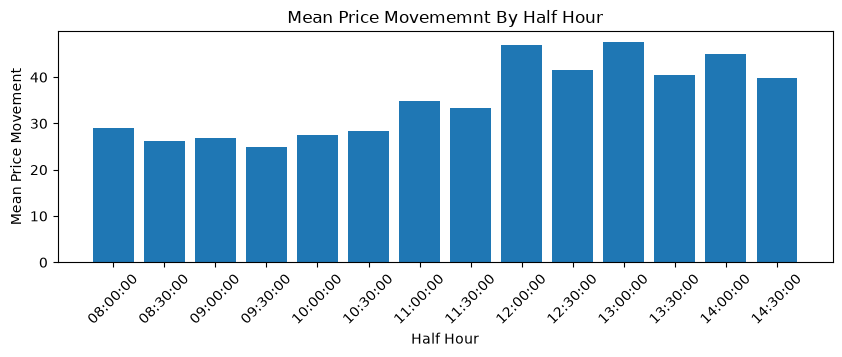

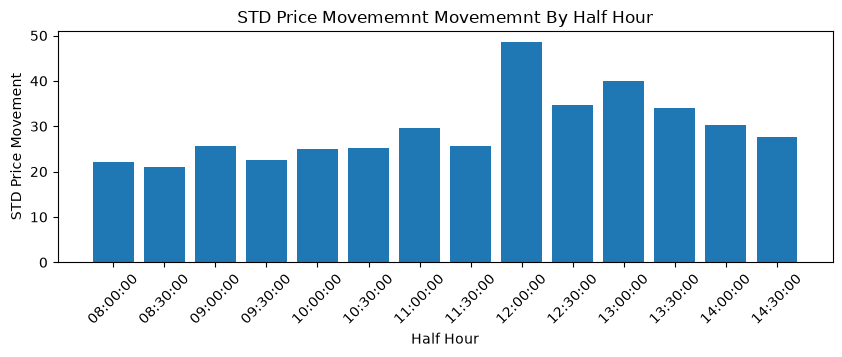

In [119]:
plt.figure(figsize=(10,3))
plt.bar(agg_30.index.astype(str),agg_30['mean'])
plt.xlabel('Half Hour')
plt.ylabel('Mean Price Movement')
plt.title('Mean Price Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,3))
plt.bar(agg_30.index.astype(str),agg_30['std'])
plt.xlabel('Half Hour')
plt.ylabel('STD Price Movement')
plt.title('STD Price Movememnt Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()

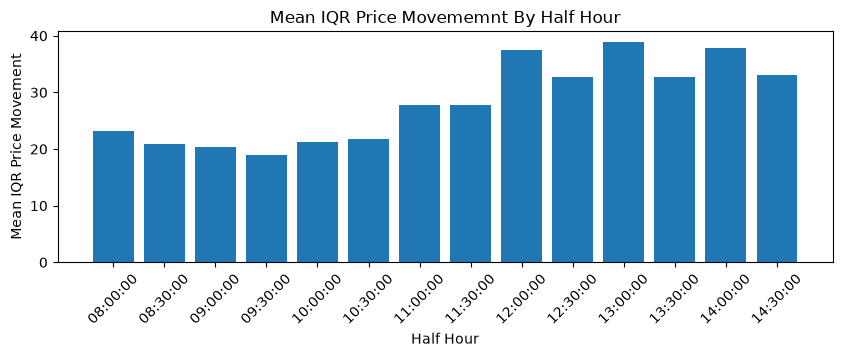

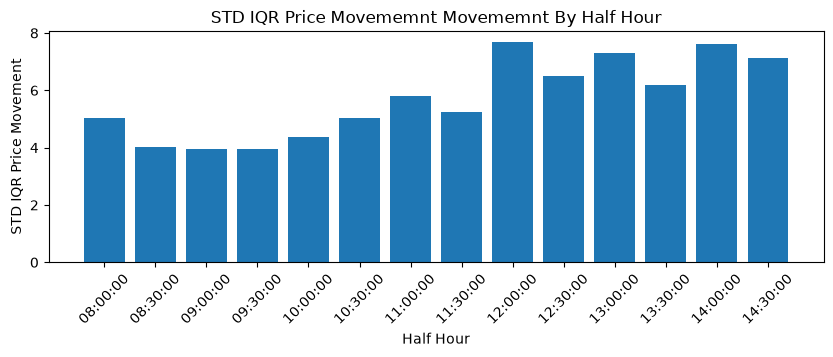

In [120]:
plt.figure(figsize=(10,3))
plt.bar(agg_30_IQR.index.astype(str),agg_30_IQR['mean'])
plt.xlabel('Half Hour')
plt.ylabel('Mean IQR Price Movement')
plt.title('Mean IQR Price Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,3))
plt.bar(agg_30_IQR.index.astype(str),agg_30_IQR['std'])
plt.xlabel('Half Hour')
plt.ylabel('STD IQR Price Movement')
plt.title('STD IQR Price Movememnt Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()

Minute Analysis

In [122]:
agg_min = df_min.groupby('bar_time')['price_movement'].agg(['mean','median','std'])
df_min['q1'] = df_min.groupby('bar_time')['price_movement'].transform(lambda x: x.quantile(.25))
df_min['q3'] = df_min.groupby('bar_time')['price_movement'].transform(lambda x: x.quantile(.75))
df_min_IQR = df_min[(df_min['price_movement']>=df_min['q1'])&(df_min['price_movement']<=df_min['q3'])]
agg_min_IQR = df_min_IQR.groupby('bar_time')['price_movement'].agg(['mean','median','std'])

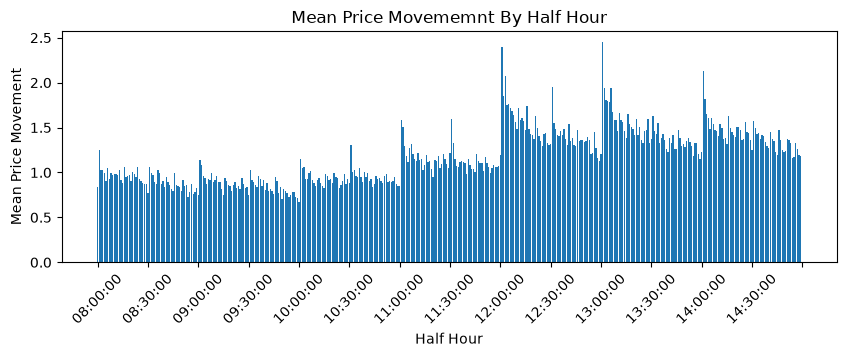

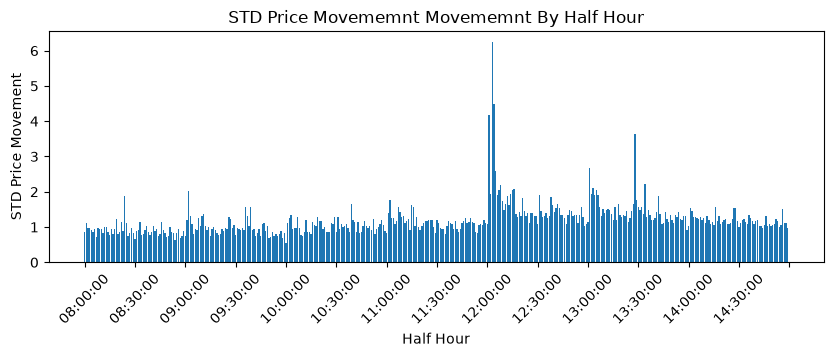

In [126]:
plt.figure(figsize=(10,3))
plt.bar(agg_min.index.astype(str),agg_min['mean'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Half Hour')
plt.ylabel('Mean Price Movement')
plt.title('Mean Price Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,3))
plt.bar(agg_min.index.astype(str),agg_min['std'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Half Hour')
plt.ylabel('STD Price Movement')
plt.title('STD Price Movememnt Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()

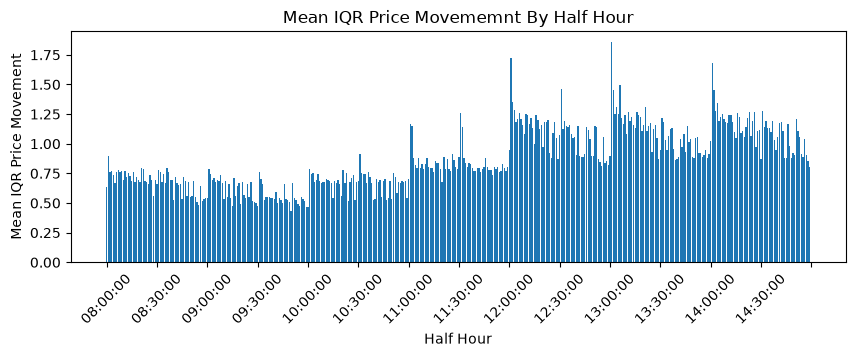

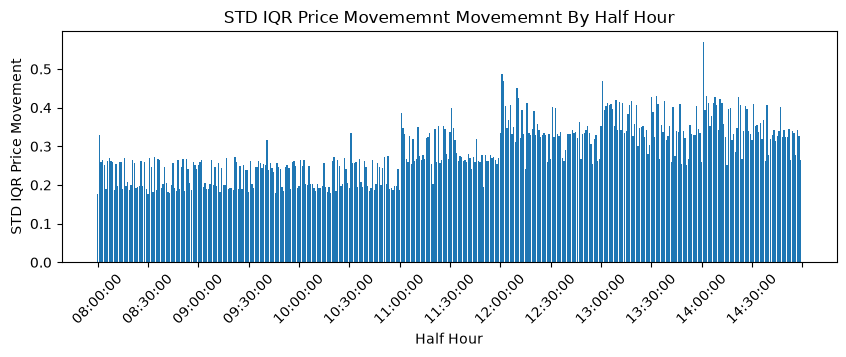

In [125]:
plt.figure(figsize=(10,3))
plt.bar(agg_min_IQR.index.astype(str),agg_min_IQR['mean'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Half Hour')
plt.ylabel('Mean IQR Price Movement')
plt.title('Mean IQR Price Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,3))
plt.bar(agg_min_IQR.index.astype(str),agg_min_IQR['std'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Half Hour')
plt.ylabel('STD IQR Price Movement')
plt.title('STD IQR Price Movememnt Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()